In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('computer_prices_all.csv')
df.head()

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


# Analisis exploratorio

In [3]:
df.shape

(100000, 33)

In [4]:
df.columns

Index(['device_type', 'brand', 'model', 'release_year', 'os', 'form_factor',
       'cpu_brand', 'cpu_model', 'cpu_tier', 'cpu_cores', 'cpu_threads',
       'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_brand', 'gpu_model', 'gpu_tier',
       'vram_gb', 'ram_gb', 'storage_type', 'storage_gb',
       'storage_drive_count', 'display_type', 'display_size_in', 'resolution',
       'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'wifi',
       'bluetooth', 'weight_kg', 'warranty_months', 'price'],
      dtype='object')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84165 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   device_type          84165 non-null  object 
 1   brand                84165 non-null  object 
 2   model                84165 non-null  object 
 3   release_year         84165 non-null  int64  
 4   os                   84165 non-null  object 
 5   form_factor          84165 non-null  object 
 6   cpu_brand            84165 non-null  object 
 7   cpu_model            84165 non-null  object 
 8   cpu_tier             84165 non-null  int64  
 9   cpu_cores            84165 non-null  int64  
 10  cpu_threads          84165 non-null  int64  
 11  cpu_base_ghz         84165 non-null  float64
 12  cpu_boost_ghz        84165 non-null  float64
 13  gpu_brand            84165 non-null  object 
 14  gpu_model            84165 non-null  object 
 15  gpu_tier             84165 non-null  int6

In [5]:
df.isnull().sum()

device_type            0
brand                  0
model                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_model              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
cpu_base_ghz           0
cpu_boost_ghz          0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
display_size_in        0
resolution             0
refresh_hz             0
battery_wh             0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64

In [6]:
df['id'] = range(1, len(df) + 1)
df = df[df["release_year"] != 2025].copy()
df.to_excel('computer_prices_all.xlsx', index=False)

## Exploracion de datos

In [25]:
df.shape

(84165, 34)

### Identificacion de outliers

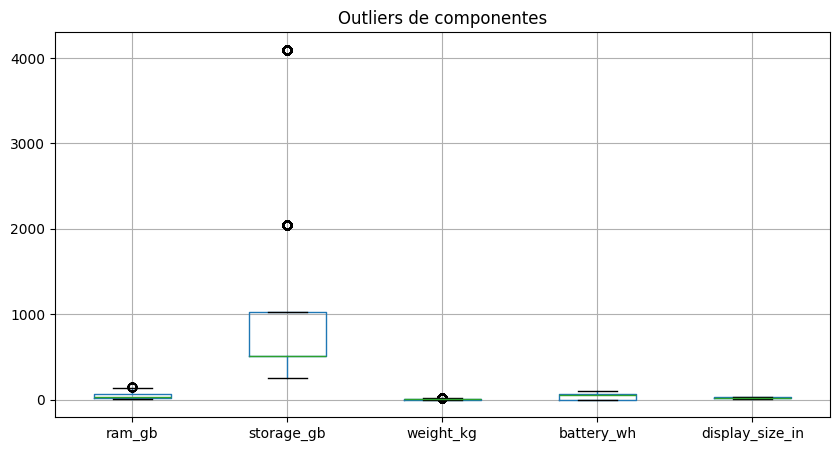

In [36]:
columnas = ["ram_gb", "storage_gb", "weight_kg", "battery_wh", "display_size_in"]
plt.figure(figsize=(10, 5))
df[columnas].boxplot()
plt.title("Outliers de componentes")
plt.show()

### analisis de datos de algunos componentes

In [7]:
df["brand"].value_counts()

brand
Lenovo      13451
HP          11932
Dell        11866
Apple        9987
ASUS         8572
Acer         8340
Samsung      6738
MSI          6628
Gigabyte     4116
Razer        2535
Name: count, dtype: int64

In [8]:
df["ram_gb"].value_counts()

ram_gb
32     18976
16     18696
8      15459
64     14371
96      7762
128     2163
24      1916
40      1671
72      1331
104      677
48       415
80       318
136      203
112      163
144       44
Name: count, dtype: int64

In [26]:
df["storage_gb"].value_counts()

storage_gb
512     29613
1024    25421
256     16641
2048     9959
4096     2531
Name: count, dtype: int64

In [9]:
df.loc[df['brand'] == 'Apple', 'ram_gb'].unique()

array([  8,  32,  96, 144,  16, 128,  64,  72,  48, 104,  24,  40, 136,
        80, 112])

In [10]:
df.loc[df["brand"] == "Apple", "ram_gb"].value_counts()

ram_gb
32     2234
64     1968
16     1782
96     1496
8      1020
128     611
72      201
40      183
24      183
104     114
80       60
136      48
48       46
112      32
144       9
Name: count, dtype: int64

In [43]:
df_laptop = df[df["device_type"] == "Laptop"]
df_desktop = df[df["device_type"] == "Desktop"]

In [47]:
print('Laptops')
df_laptop[["battery_wh", "charger_watts"]].describe()

Laptops


,battery_wh,charger_watts
count,50356.000000,50356.000000
mean,69.893776,102.622627
std,13.769441,48.605888
min,50.000000,45.000000
25%,60.000000,65.000000
50%,70.000000,90.000000
75%,80.000000,120.000000
max,99.000000,240.000000


In [48]:
print('Desktop')
df_desktop[["battery_wh", "charger_watts"]].describe()

Desktop


,battery_wh,charger_watts
count,33809.0,33809.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


### cpu_tier

In [11]:
df["cpu_tier"].unique()

array([3, 4, 2, 5, 6, 1])

In [12]:
df["cpu_tier"].value_counts().sort_index()

cpu_tier
1    10813
2    17908
3    21699
4    18736
5    10902
6     4107
Name: count, dtype: int64

In [13]:
df.groupby("cpu_tier")["cpu_model"].value_counts()

cpu_tier  cpu_model     
1         Apple M2 Pro      75
          Apple M3          71
          Apple M3 Max      66
          Apple M2          62
          Apple M1          57
                            ..
6         Intel i9-14984     1
          Intel i9-14988     1
          Intel i9-14989     1
          Intel i9-14993     1
          Intel i9-14997     1
Name: count, Length: 36919, dtype: int64

In [14]:
df.groupby("cpu_tier")[["cpu_cores", "cpu_threads", "cpu_boost_ghz"]].mean() #para saber que compone la escala del 1 al 6 de cpu_tier

,cpu_cores,cpu_threads,cpu_boost_ghz
cpu_tier,,,
1,4.743549,9.061870,3.101591
2,6.778981,12.757874,3.304981
3,8.758560,16.372460,3.500760
4,12.767933,23.705167,3.696483
5,16.760961,30.520455,3.898725
6,24.754809,42.576577,4.102143


In [15]:
df.loc[df["cpu_tier"] == 1, "cpu_cores"].unique()

array([4, 6, 8])

In [16]:
df.loc[df["cpu_tier"] == 2, "cpu_cores"].unique()

array([ 8,  6, 10])

In [17]:
df.loc[df["cpu_tier"] == 3, "cpu_cores"].unique()

array([12,  8, 10])

In [18]:
df.loc[df["cpu_tier"] == 4, "cpu_cores"].unique()

array([12, 14, 16])

In [19]:
df.loc[df["cpu_tier"] == 5, "cpu_cores"].unique()

array([16, 18, 20])

In [20]:
df.loc[df["cpu_tier"] == 6, "cpu_cores"].unique()

array([26, 24, 28])

# Correlacion

# PCA

In [22]:
df.dtypes != object

device_type            False
brand                  False
model                  False
release_year            True
os                     False
form_factor            False
cpu_brand              False
cpu_model              False
cpu_tier                True
cpu_cores               True
cpu_threads             True
cpu_base_ghz            True
cpu_boost_ghz           True
gpu_brand              False
gpu_model              False
gpu_tier                True
vram_gb                 True
ram_gb                  True
storage_type           False
storage_gb              True
storage_drive_count     True
display_type           False
display_size_in         True
resolution             False
refresh_hz              True
battery_wh              True
charger_watts           True
psu_watts               True
wifi                   False
bluetooth               True
weight_kg               True
warranty_months         True
price                   True
id                      True
dtype: bool

In [23]:
columnas_num = ["release_year", "cpu_tier", "cpu_cores","cpu_threads","cpu_base_ghz", "cpu_boost_ghz", "gpu_tier", "vram_gb","ram_gb", "storage_gb", 
    "storage_drive_count", "display_size_in", "refresh_hz", "battery_wh", "charger_watts", "psu_watts", "bluetooth", "weight_kg","warranty_months",
    "price", "id"]

X = df[columnas_num]

In [24]:
from sklearn.preprocessing import StandardScaler #estandarizamos los datos 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
#qplicamos PCA
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [ ]:
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca_3,columns=["1", "2", "3"])
df_pca

In [ ]:
loadings = pd.DataFrame( #CHAT 
    pca_3.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=X.columns
)

loadings.sort_values("PC1", ascending=False)

In [ ]:
pd.DataFrame({ #CHAT
    "Componente": ["PC1", "PC2", "PC3"],
    "Varianza explicada": pca_3.explained_variance_ratio_,
    "Varianza acumulada": pca_3.explained_variance_ratio_.cumsum()
})